In [23]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score,mean_squared_error,mean_absolute_error
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
data_set=pd.read_csv('Student_Performance.csv')

In [7]:
data_set.head()

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,Yes,9,1,91.0
1,4,82,No,4,2,65.0
2,8,51,Yes,7,2,45.0
3,5,52,Yes,5,2,36.0
4,7,75,No,8,5,66.0


In [8]:
data_set.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Hours Studied                     10000 non-null  int64  
 1   Previous Scores                   10000 non-null  int64  
 2   Extracurricular Activities        10000 non-null  object 
 3   Sleep Hours                       10000 non-null  int64  
 4   Sample Question Papers Practiced  10000 non-null  int64  
 5   Performance Index                 10000 non-null  float64
dtypes: float64(1), int64(4), object(1)
memory usage: 468.9+ KB


In [9]:
# Correct way to drop a column from a DataFrame
data_set = data_set.drop('Extracurricular Activities', axis=1)


x= data_set.iloc[:, :-1].values
y= data_set.iloc[:, 1].values

In [10]:
x

array([[ 7, 99,  9,  1],
       [ 4, 82,  4,  2],
       [ 8, 51,  7,  2],
       ...,
       [ 6, 83,  8,  5],
       [ 9, 97,  7,  0],
       [ 7, 74,  8,  1]], dtype=int64)

In [11]:
y

array([99, 82, 51, ..., 83, 97, 74], dtype=int64)

In [12]:
x_train, x_test, y_train, y_test= train_test_split(x, y, test_size= 1/3, random_state=0)

regressor= LinearRegression()
regressor.fit(x_train, y_train)

LinearRegression()

In [25]:
y_test_pred = regressor.predict(x_test)
y_train_pred = regressor.predict(x_train)
 

In [26]:
y_test_pred

array([67., 60., 90., ..., 43., 44., 77.])

In [27]:
y_train_pred

array([87., 87., 83., ..., 76., 44., 83.])

In [28]:
test_r2 = r2_score(y_test, y_test_pred)
train_r2 = r2_score(y_train, y_train_pred) 

R-squared score on training data: 1.000
R-squared score on test data: 1.000
Mean Squared Error on test data: 0.000
Mean Squared Error on training data: 0.000
Mean Absolute Error (MAE): 0.000


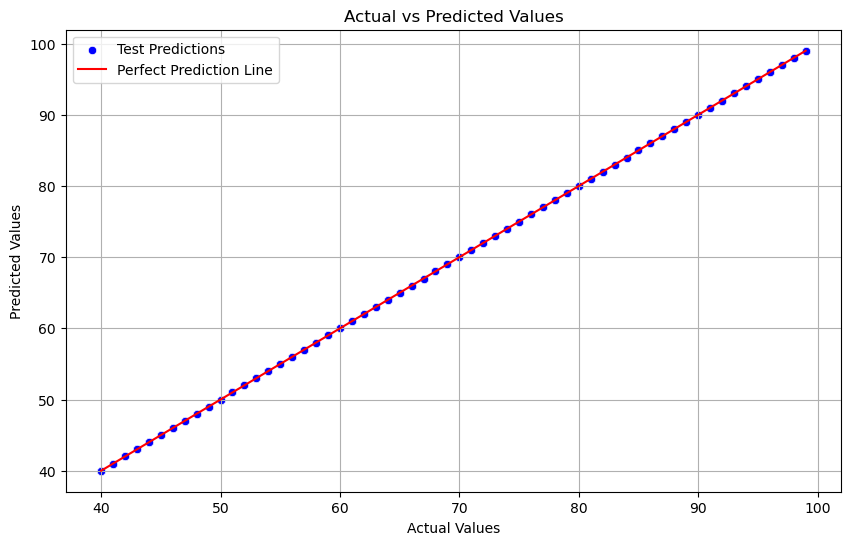

In [30]:
print(f"R-squared score on training data: {train_r2:.3f}")
print(f"R-squared score on test data: {test_r2:.3f}") 

mse_test = mean_squared_error(y_test, y_test_pred)
mse_train = mean_squared_error(y_train, y_train_pred)

print(f"Mean Squared Error on test data: {mse_test:.3f}")
print(f"Mean Squared Error on training data: {mse_train:.3f}")

mae = mean_absolute_error(y_train, y_train_pred)
print(f"Mean Absolute Error (MAE): {mae:.3f}")

plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_test_pred, color='blue', label='Test Predictions')
sns.lineplot(x=[min(y_test), max(y_test)], y=[min(y_test), max(y_test)], color='red', label='Perfect Prediction Line')

plt.title('Actual vs Predicted Values')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.legend()
plt.grid()
plt.show()